In [43]:
import yfinance

Stock_Ticker = "AMD"

Start_Date = "2019-01-01"

End_Date = "2024-01-01"

dataframe = yfinance.download(tickers = Stock_Ticker,
                 start = Start_Date,
                 end = End_Date)
dataframe

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMD,AMD,AMD,AMD,AMD
Date,,,,,
2019-01-02,18.830000,19.000000,17.980000,18.010000,87148700
2019-01-03,17.049999,18.680000,16.940001,18.420000,117277600
2019-01-04,19.000000,19.070000,17.430000,17.549999,111878600
2019-01-07,20.570000,20.680000,19.000000,19.440001,107157000
2019-01-08,20.750000,21.200001,19.680000,21.190001,121271000
...,...,...,...,...,...
2023-12-22,139.600006,140.699997,138.309998,140.479996,35370400
2023-12-26,143.410004,143.850006,139.919998,140.070007,47157400


In [44]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AMD)   1258 non-null   float64
 1   (High, AMD)    1258 non-null   float64
 2   (Low, AMD)     1258 non-null   float64
 3   (Open, AMD)    1258 non-null   float64
 4   (Volume, AMD)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [45]:
X = dataframe.iloc[:, 1].values

X

array([ 19.        ,  18.68000031,  19.06999969, ..., 146.25      ,
       150.41000366, 151.05000305])

In [46]:
X.shape

(1258,)

In [47]:
y = dataframe.iloc[:, 0].values

y

array([ 18.82999992,  17.04999924,  19.        , ..., 146.07000732,
       148.75999451, 147.41000366])

In [48]:
y.shape

(1258,)

In [49]:
import numpy

Number_Of_Rows = 1258

X = numpy.array(X).reshape(Number_Of_Rows, -1)

X

array([[ 19.        ],
       [ 18.68000031],
       [ 19.06999969],
       ...,
       [146.25      ],
       [150.41000366],
       [151.05000305]])

In [50]:
X.shape

(1258, 1)

In [51]:
y = numpy.array(y).reshape(Number_Of_Rows, -1)

y

array([[ 18.82999992],
       [ 17.04999924],
       [ 19.        ],
       ...,
       [146.07000732],
       [148.75999451],
       [147.41000366]])

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/5, random_state = 0)

X_train

array([[ 31.30999947],
       [ 77.91000366],
       [ 84.75      ],
       ...,
       [ 98.81999969],
       [ 80.33999634],
       [102.51000214]])

In [53]:
X_train.shape

(1006, 1)

In [54]:
y_train.shape

(1006, 1)

In [55]:
X_test.shape

(252, 1)

In [56]:
y_test.shape

(252, 1)

In [57]:
print(X_train)

[[ 31.30999947]
 [ 77.91000366]
 [ 84.75      ]
 ...
 [ 98.81999969]
 [ 80.33999634]
 [102.51000214]]


In [58]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model = model.fit(X_train, y_train)

model

LinearRegression()

In [59]:
prediction = model.predict(X_test)

prediction

array([[ 21.10507903],
       [ 95.31303058],
       [ 25.64582633],
       [ 73.02030828],
       [ 29.25689576],
       [ 20.07753798],
       [ 46.68593159],
       [ 96.97667115],
       [ 54.53437617],
       [ 81.92565287],
       [ 80.26201977],
       [151.16227217],
       [ 84.98870526],
       [ 77.60998903],
       [143.67591578],
       [128.1160164 ],
       [117.95806036],
       [111.5775225 ],
       [ 27.03545184],
       [112.62463432],
       [ 79.28341031],
       [ 31.47833968],
       [119.08345527],
       [ 93.49282386],
       [110.85335359],
       [ 34.37502279],
       [ 92.0053333 ],
       [ 88.12025254],
       [ 82.96298398],
       [ 92.21084039],
       [ 31.36090572],
       [ 89.80346201],
       [111.30351304],
       [ 21.74117481],
       [ 91.58453093],
       [ 96.35036169],
       [123.10554074],
       [ 95.48918059],
       [ 86.24132417],
       [ 45.93240185],
       [ 49.88598124],
       [107.51629175],
       [ 71.22945864],
       [ 97

In [60]:
prediction.shape

(252, 1)

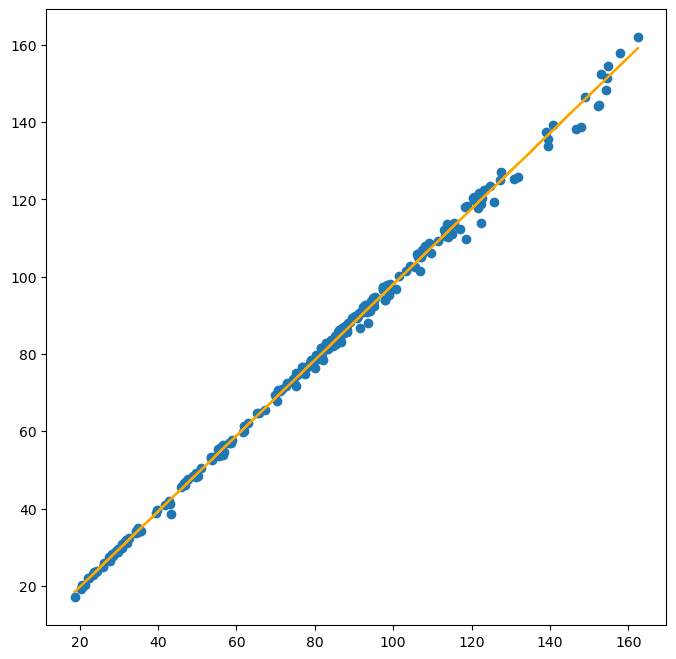

In [61]:
import matplotlib.pyplot as pyplot

pyplot.figure(figsize = (8, 8))

pyplot.scatter(X_test, y_test)

pyplot.plot(X_test, prediction, color = "orange")

In [62]:
model.score(X_test, y_test)

0.9978227547538426

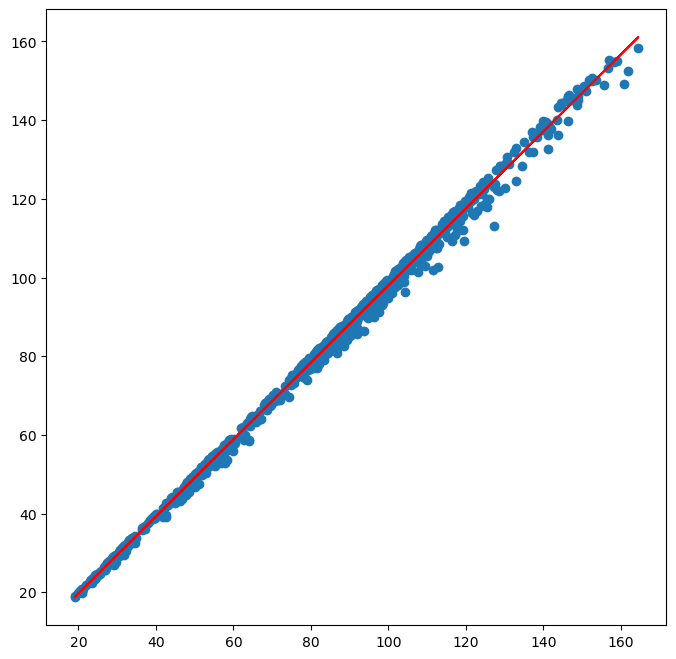

In [63]:
pyplot.figure(figsize = (8, 8))

pyplot.scatter(X_train, y_train)

training_predictions = model.predict(X_train)

pyplot.plot(X_train, training_predictions, color = "red")

In [64]:
model.score(X_train, y_train)

0.9978831894402355